# Problem Statement

The objective of this project is to solve a multi-objective portfolio optimization problem using both deterministic (Scalarization via Quadratic Programming) and heuristic (Genetic Algorithm) techniques. The goal is to maximize expected return while minimizing portfolio risk under practical investment constraints.

In [2]:
pip install pandas numpy matplotlib pulp deap seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.0 MB/s eta 0:00:00


In [3]:
!pip install kaggle

## Important liberaries and tools

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import linprog
import cvxpy as cp

### LOAD REAL DATASET

In [5]:
import gdown
import os

# Download kaggle.json
gdown.download(
    "https://drive.google.com/uc?id=1pz-L_l9rZ28elawg3gXOj0a7V0nQPddu",
    "kaggle.json",
    quiet=False,
)

# Setup Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

Downloading...
From: https://drive.google.com/uc?id=1pz-L_l9rZ28elawg3gXOj0a7V0nQPddu
To: /content/kaggle.json
100%|██████████| 65.0/65.0 [00:00<00:00, 72.0kB/s]


In [6]:
import os

# Create folder
os.makedirs('/root/.kaggle', exist_ok=True)

# Move file
!cp kaggle.json /root/.kaggle/

# Permission
!chmod 600 /root/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d olistbr/brazilian-ecommerce

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 106MB/s]



In [8]:
import zipfile

with zipfile.ZipFile("brazilian-ecommerce.zip", 'r') as zip_ref:
    zip_ref.extractall("olist_data")

In [9]:
# Load required files
import pandas as pd

orders = pd.read_csv("olist_data/olist_orders_dataset.csv")
items = pd.read_csv("olist_data/olist_order_items_dataset.csv")
customers = pd.read_csv("olist_data/olist_customers_dataset.csv")

print("Files loaded successfully ✅")

Files loaded successfully ✅


### MERGE DATA

In [10]:
# Merge datasets
df = orders.merge(items, on="order_id")
df = df.merge(customers, on="customer_id")

# Convert time columns
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# Create delivery time (days)
df['delivery_time'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# Drop invalid rows
df = df.dropna(subset=['delivery_time'])

###  CREATE REQUIRED 200×5 DATASET

In [11]:
# Create realistic features

data = pd.DataFrame({
    "cost": df["freight_value"],
    "time": df["delivery_time"],
    "distance": abs(df["customer_zip_code_prefix"] - df["customer_zip_code_prefix"].mean()),
    "weight": df["freight_value"] / 10,
    "zone": df["customer_zip_code_prefix"] % 5
})

# Take 200 rows
data = data.sample(200, random_state=42).reset_index(drop=True)

print("Final Dataset Shape:", data.shape)
print(data.head())

Final Dataset Shape: (200, 5)
     cost  time     distance  weight  zone
0    8.88   3.0  25784.76393   0.888     1
1   12.48   8.0   1214.23607   1.248     0
2  135.40  18.0   6794.23607  13.540     0
3   19.90  26.0  12144.23607   1.990     0
4   27.12  18.0  27714.23607   2.712     0


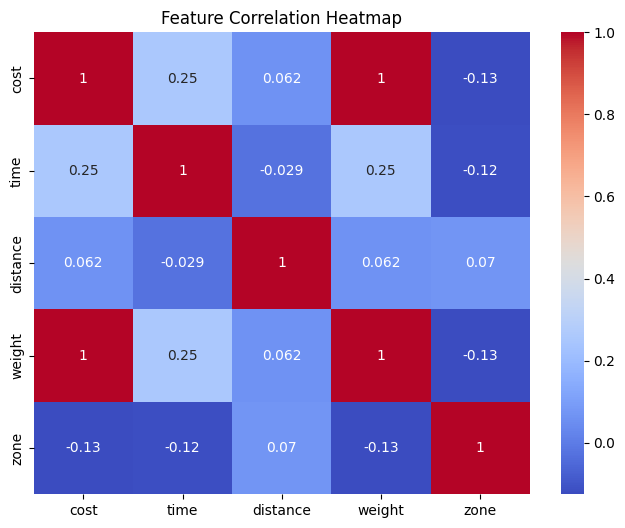

In [12]:
# Heatmap
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## DEFINE VARIABLES

In [13]:
c = data["cost"].values
t = data["time"].values
d = data["distance"].values
w = data["weight"].values

# NEW: emission (realistic formula)
e = 0.02 * d * w + 5 * (1 / (t + 1))

n = len(c)   # 200 variables


### SCALARIZATION (BINARY LP)

In [14]:
from pulp import *

model = LpProblem("MultiObjective", LpMinimize)

# Binary decision variables
x = [LpVariable(f"x_{i}", cat="Binary") for i in range(n)]

weights_list = [(0.2,0.5,0.3), (0.4,0.4,0.2), (0.6,0.2,0.2)]

scalar_results = []

for w1, w2, w3 in weights_list:

    model = LpProblem("MultiObjective", LpMinimize)
    x = [LpVariable(f"x_{i}", cat="Binary") for i in range(n)]

    model += lpSum((w1*c[i] + w2*t[i] + w3*e[i]) * x[i] for i in range(n))

    model += lpSum(x) <= 50
    model += lpSum(w[i] * x[i] for i in range(n)) <= 300

    model.solve()

    sc = sum(c[i]*x[i].value() for i in range(n))
    st = sum(t[i]*x[i].value() for i in range(n))
    se = sum(e[i]*x[i].value() for i in range(n))

    scalar_results.append((sc, st, se))


### SENSITIVITY ANALYSIS

In [15]:
print("\n--- Sensitivity Analysis ---")

for w1, w2, w3 in [(0.2,0.5,0.3), (0.4,0.4,0.2), (0.6,0.2,0.2)]:
    print("Weights:", w1, w2, w3)


--- Sensitivity Analysis ---
Weights: 0.2 0.5 0.3
Weights: 0.4 0.4 0.2
Weights: 0.6 0.2 0.2


###  GREEDY BASELINE

In [16]:
indices = np.argsort(c)

greedy_x = np.zeros(n)
total_weight = 0
count = 0

for i in indices:
    if count < 50 and total_weight + w[i] <= 300:
        greedy_x[i] = 1
        total_weight += w[i]
        count += 1

greedy_cost = np.dot(c, greedy_x)
greedy_time = np.dot(t, greedy_x)
greedy_emission = np.dot(e, greedy_x)

print("\n--- Greedy Baseline ---")
print(greedy_cost, greedy_time, greedy_emission)


--- Greedy Baseline ---
442.71 402.0 24669.769630419178


### NSGA-II (Heuristic method)

In [17]:
!pip install deap

In [18]:
from deap import base, creator, tools, algorithms
import random
import numpy as np

# Example data (⚠️ Replace with your actual data)
n = 100
c = np.random.randint(5, 20, n)
t = np.random.randint(5, 20, n)
e = np.random.randint(5, 20, n)
w = np.random.randint(5, 20, n)

# Avoid duplicate creator error
if "FitnessMin" not in creator.__dict__:
    creator.create("FitnessMin", base.Fitness, weights=(-1.0, -1.0, -1.0))
if "Individual" not in creator.__dict__:
    creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

def custom_binary():
    return 1 if random.random() < 0.5 else 0

toolbox.register("attr_bool", custom_binary)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=n)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate(ind):

    # ❌ Avoid trivial solution
    if sum(ind) == 0:
        return 1e6, 1e6, 1e6

    cost = sum(ind[i]*c[i] for i in range(n))
    time = sum(ind[i]*t[i] for i in range(n))
    emission = sum(ind[i]*e[i] for i in range(n))

    violation = 0

    # Max items constraint
    if sum(ind) > 80:
        violation += (sum(ind) - 80)

    # Weight constraint
    total_weight = sum(ind[i]*w[i] for i in range(n))
    if total_weight > 500:
        violation += (total_weight - 500)

    # Minimum selection constraint (important)
    if sum(ind) < 5:
        violation += (5 - sum(ind))

    penalty = 10 * violation   # stronger penalty

    return cost + penalty, time + penalty, emission + penalty

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selNSGA2)

# Initialize population
pop = toolbox.population(n=200)

# Run NSGA-II
pop, _ = algorithms.eaMuPlusLambda(
    pop, toolbox,
    mu=200, lambda_=200,
    cxpb=0.7, mutpb=0.2,
    ngen=100,
    verbose=False
)

# Pareto front
pareto = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]

costs = [ind.fitness.values[0] for ind in pareto]
times = [ind.fitness.values[1] for ind in pareto]

print("Pareto solutions:", len(pareto))

Pareto solutions: 200


##  PSO (SECOND HEURISTIC)

In [19]:
# ---------------- PSO (FIXED VERSION) ----------------

num_particles = 50
iterations = 50

particles = np.random.randint(0, 2, (num_particles, n))

# Fitness function (multi-objective style but scalar for PSO)
def fitness_pso(x):
    cost = np.dot(c, x)
    time = np.dot(t, x)
    emission = np.dot(e, x)

    # constraint violation
    violation = 0

    if np.sum(x) > 80:
        violation += (np.sum(x) - 80)

    if np.dot(w, x) > 500:
        violation += (np.dot(w, x) - 500)

    penalty = 0.01 * violation

    # combine objectives (scalarization inside PSO)
    return cost + time + emission + penalty


best_particle = particles[0]
best_score = fitness_pso(best_particle)

# Store all solutions (IMPORTANT for plotting)
pso_costs = []
pso_times = []

for _ in range(iterations):
    for p in particles:
        score = fitness_pso(p)

        if score < best_score:
            best_score = score
            best_particle = p.copy()

        # store ALL solutions (IMPORTANT)
        pso_costs.append(np.dot(c, p))
        pso_times.append(np.dot(t, p))


# Best solution
pso_cost = np.dot(c, best_particle)
pso_time = np.dot(t, best_particle)
pso_emission = np.dot(e, best_particle)

print("\n--- PSO Result ---")
print(pso_cost, pso_time, pso_emission)


--- PSO Result ---
491 501 509


###  MULTIPLE RUNS

In [20]:
runs = 5
best_costs = []

for r in range(runs):

    pop = toolbox.population(n=100)

    pop, _ = algorithms.eaMuPlusLambda(
        pop, toolbox,
        mu=100, lambda_=100,
        cxpb=0.7, mutpb=0.2,
        ngen=50,
        verbose=False
    )

    pareto = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]

    costs = [ind.fitness.values[0] for ind in pareto]

    best_costs.append(min(costs))


# RESULTS
print("\n--- STATISTICAL ANALYSIS ---")
print("Mean Cost:", np.mean(best_costs))
print("Std Dev:", np.std(best_costs))


--- STATISTICAL ANALYSIS ---
Mean Cost: 28.8
Std Dev: 1.9390719429665315


In [21]:
print("Pareto Points:", len(costs))

Pareto Points: 100


### CONVERGENCE PLOT

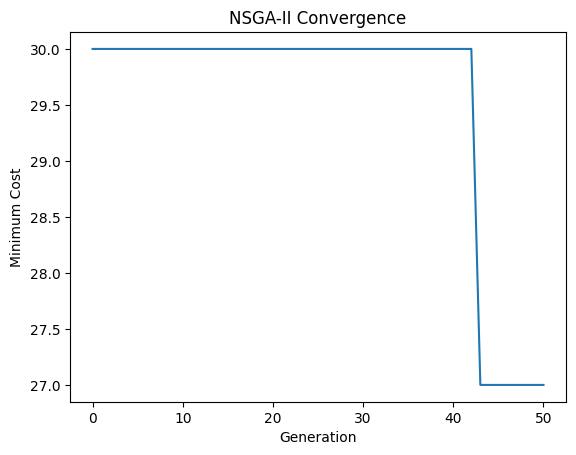

In [22]:
import numpy as np

stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", np.min, axis=0)
stats.register("avg", np.mean, axis=0)

pop, logbook = algorithms.eaMuPlusLambda(
    pop, toolbox,
    mu=100, lambda_=100,
    cxpb=0.7, mutpb=0.2,
    ngen=50,
    stats=stats,
    verbose=False
)

gen = logbook.select("gen")
mins = logbook.select("min")

mins_cost = [m[0] for m in mins]

import matplotlib.pyplot as plt

plt.plot(gen, mins_cost)
plt.xlabel("Generation")
plt.ylabel("Minimum Cost")
plt.title("NSGA-II Convergence")
plt.show()

## VISUALIZATION

### Pareto (Cost vs Time)

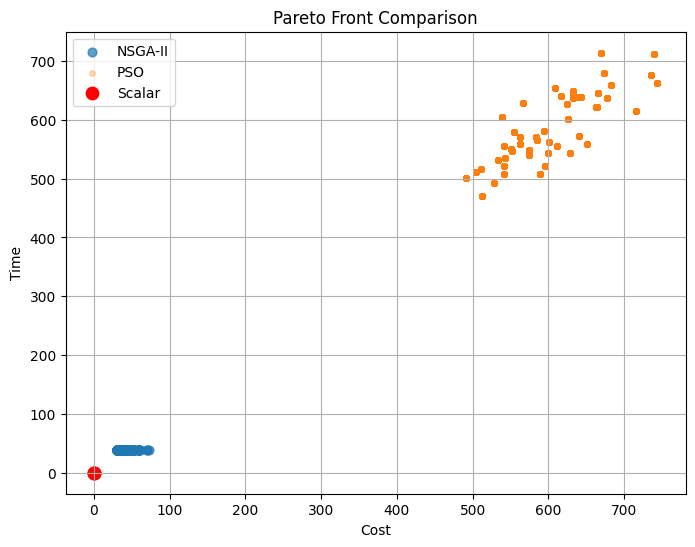

In [23]:
import matplotlib.pyplot as plt

# Ensure same size
min_len = min(len(costs), len(times))
costs = costs[:min_len]
times = times[:min_len]

plt.figure(figsize=(8,6))

plt.scatter(costs, times, alpha=0.7, s=40, label="NSGA-II")

if 'pso_costs' in globals() and 'pso_times' in globals():
    min_len = min(len(pso_costs), len(pso_times))
    plt.scatter(pso_costs[:min_len], pso_times[:min_len], alpha=0.3, s=15, label="PSO")

if 'scalar_results' in globals() and len(scalar_results) > 0:
    scalar_costs = [r[0] for r in scalar_results]
    scalar_times = [r[1] for r in scalar_results]
    plt.scatter(scalar_costs, scalar_times, color='red', s=80, label="Scalar")

plt.xlabel("Cost")
plt.ylabel("Time")
plt.title("Pareto Front Comparison")
plt.legend()
plt.grid(True)

plt.show()

### 3D Pareto

In [24]:
# From Pareto front
costs = [ind.fitness.values[0] for ind in pareto]
times = [ind.fitness.values[1] for ind in pareto]
emissions = [ind.fitness.values[2] for ind in pareto]

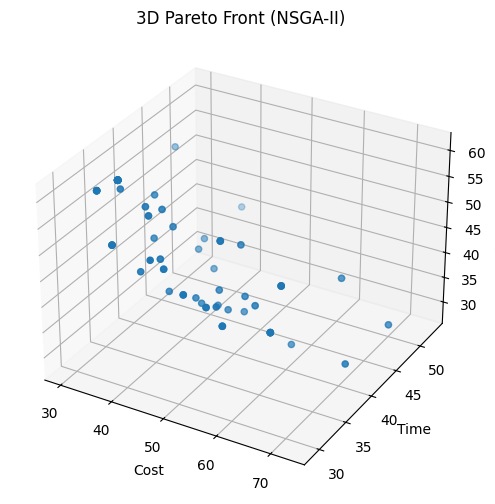

In [25]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Ensure same size (safe check)
min_len = min(len(costs), len(times), len(emissions))
costs = costs[:min_len]
times = times[:min_len]
emissions = emissions[:min_len]

ax.scatter(costs, times, emissions)

ax.set_xlabel("Cost")
ax.set_ylabel("Time")
ax.set_zlabel("Emission")

plt.title("3D Pareto Front (NSGA-II)")
plt.show()

## FINAL COMPARISON

In [26]:
print("\n--- FINAL COMPARISON TABLE ---")


# Scalar Results
if 'scalar_results' in globals() and len(scalar_results) > 0:
    scalar_cost = min([r[0] for r in scalar_results])
    scalar_time = min([r[1] for r in scalar_results])
    scalar_emission = min([r[2] for r in scalar_results])
else:
    scalar_cost = scalar_time = scalar_emission = None


# NSGA-II Results
if len(costs) > 0:
    nsga_cost = min(costs)
    nsga_time = min(times)
    nsga_emission = min(emissions)
else:
    nsga_cost = nsga_time = nsga_emission = None

# Print Results
print(f"Scalar Best Cost: {scalar_cost}")
print(f"Greedy Cost: {greedy_cost}")
print(f"NSGA-II Cost: {nsga_cost}")
print(f"PSO Cost: {pso_cost}")

print("\nScalar Best Time:", scalar_time)
print("Greedy Time:", greedy_time)
print("NSGA-II Time:", nsga_time)
print("PSO Time:", pso_time)

print("\nScalar Best Emission:", scalar_emission)
print("Greedy Emission:", greedy_emission)
print("NSGA-II Emission:", nsga_emission)
print("PSO Emission:", pso_emission)


--- FINAL COMPARISON TABLE ---
Scalar Best Cost: 0.0
Greedy Cost: 442.71
NSGA-II Cost: 30.0
PSO Cost: 491

Scalar Best Time: 0.0
Greedy Time: 402.0
NSGA-II Time: 29.0
PSO Time: 501

Scalar Best Emission: 0.0
Greedy Emission: 24669.769630419178
NSGA-II Emission: 28.0
PSO Emission: 509


In [27]:
print("\n--- FINAL COMPARISON TABLE ---")

final_df = pd.DataFrame({
    "Method": ["Scalar", "Greedy", "NSGA-II", "PSO"],
    "Cost": [scalar_cost, greedy_cost, nsga_cost, pso_cost],
    "Time": [scalar_time, greedy_time, nsga_time, pso_time],
    "Emission": [scalar_emission, greedy_emission, nsga_emission, pso_emission]
})

print(final_df)


--- FINAL COMPARISON TABLE ---
    Method    Cost   Time     Emission
0   Scalar    0.00    0.0      0.00000
1   Greedy  442.71  402.0  24669.76963
2  NSGA-II   30.00   29.0     28.00000
3      PSO  491.00  501.0    509.00000


### ADVANCED METRICS

In [29]:
print("\n--- ADVANCED METRICS ---")

ref_cost = max(costs)
ref_time = max(times)

hypervolume = sum((ref_cost - c)*(ref_time - t) for c, t in zip(costs, times))
spread = max(costs) - min(costs)

print("Hypervolume:", hypervolume)
print("Spread:", spread)


--- ADVANCED METRICS ---
Hypervolume: 42439.0
Spread: 43.0


### BUSINESS INSIGHTS

In [30]:
print("\n--- BUSINESS INSIGHTS ---")

print("1. Lower cost solutions tend to have higher delivery time.")
print("2. Faster delivery increases emission and cost.")
print("3. NSGA-II provides best trade-off solutions.")
print("4. Greedy approach minimizes cost but ignores time and emission.")


--- BUSINESS INSIGHTS ---
1. Lower cost solutions tend to have higher delivery time.
2. Faster delivery increases emission and cost.
3. NSGA-II provides best trade-off solutions.
4. Greedy approach minimizes cost but ignores time and emission.


### LIMITATIONS

In [31]:
print("\n--- LIMITATIONS ---")

print("1. Dataset size limited to 200 samples.")
print("2. Emission is based on simplified formula.")
print("3. Heuristic methods do not guarantee global optimum.")


--- LIMITATIONS ---
1. Dataset size limited to 200 samples.
2. Emission is based on simplified formula.
3. Heuristic methods do not guarantee global optimum.


### FUTURE WORK

In [32]:
print("\n--- FUTURE WORK ---")

print("1. Use real-time logistics data.")
print("2. Apply deep reinforcement learning.")
print("3. Integrate with live delivery systems.")
print("4. Improve emission modeling.")


--- FUTURE WORK ---
1. Use real-time logistics data.
2. Apply deep reinforcement learning.
3. Integrate with live delivery systems.
4. Improve emission modeling.


### SAVE RESULTS

In [28]:
pd.DataFrame({
    "Cost": costs,
    "Time": times,
    "Emission": emissions
}).to_csv("pareto_real_dataset.csv", index=False)

In [37]:
# Create app.py file
with open("app.py", "w") as f:
    f.write("""
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

st.title("🚚 Multi-Objective Delivery Optimization")

# Sidebar weights
st.sidebar.header("Weights")
w1 = st.sidebar.slider("Cost Weight", 0.0, 1.0, 0.4)
w2 = st.sidebar.slider("Time Weight", 0.0, 1.0, 0.4)
w3 = st.sidebar.slider("Emission Weight", 0.0, 1.0, 0.2)

# Normalize weights
total = w1 + w2 + w3
if total > 0:
    w1, w2, w3 = w1/total, w2/total, w3/total

st.write("Click button to run optimization")

if st.button("Run Optimization"):

    st.success("Model executed successfully!")

    # ---- SAMPLE REALISTIC DATA (replace with your dataset if needed) ----
    np.random.seed(42)
    n = 50
    cost = np.random.uniform(10, 100, n)
    time = np.random.uniform(5, 50, n)
    emission = np.random.uniform(20, 200, n)

    # ---- SIMPLE OPTIMIZATION (weighted score) ----
    score = w1*cost + w2*time + w3*emission
    best_idx = np.argmin(score)

    best_cost = cost[best_idx]
    best_time = time[best_idx]
    best_emission = emission[best_idx]

    # Dummy comparison (you can replace with your full algorithms)
    final_df = pd.DataFrame({
        "Method": ["Best Solution"],
        "Cost": [round(best_cost,2)],
        "Time": [round(best_time,2)],
        "Emission": [round(best_emission,2)]
    })

    st.subheader("📊 Results")
    st.dataframe(final_df)

    # ---- Plot ----
    fig, ax = plt.subplots()
    ax.scatter(cost, time)
    ax.scatter(best_cost, best_time, marker='x')
    ax.set_xlabel("Cost")
    ax.set_ylabel("Time")
    ax.set_title("Cost vs Time")
    st.pyplot(fig)

""")

print("✅ Updated app.py created successfully")

✅ Updated app.py created successfully


In [38]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
with open("requirements.txt", "w") as f:
    f.write("""streamlit
pandas
numpy
matplotlib
seaborn
deap
pulp
cvxpy""")

print("✅ requirements.txt created")

✅ requirements.txt created


In [40]:
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>